--- Starting Grid Simulation (N=1000, Days=60) ---
Simulating: Norm=0, Multi=1...
[Visualizing first detected failed run at r=0]


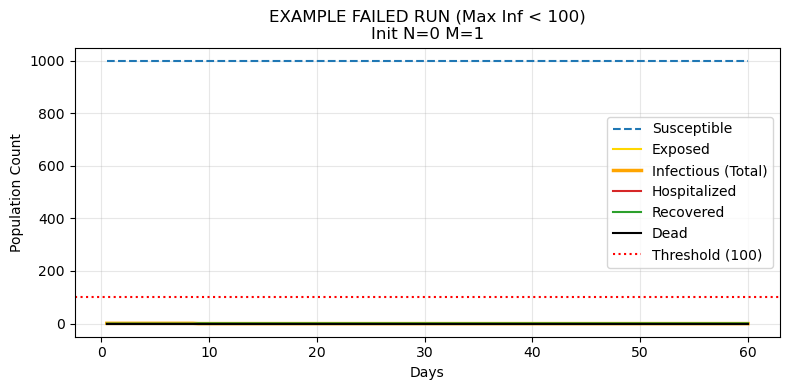


[Visualizing first detected failed run at r=4]


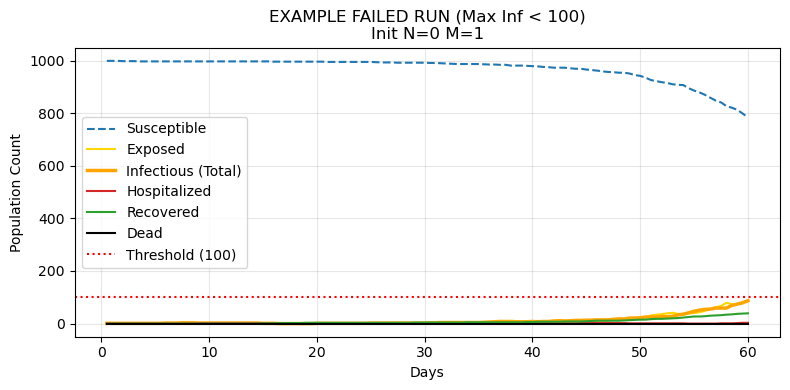

 Done. (Failed: 2/10) (28.06s)
Simulating: Norm=1, Multi=0...
[Visualizing first detected failed run at r=0]


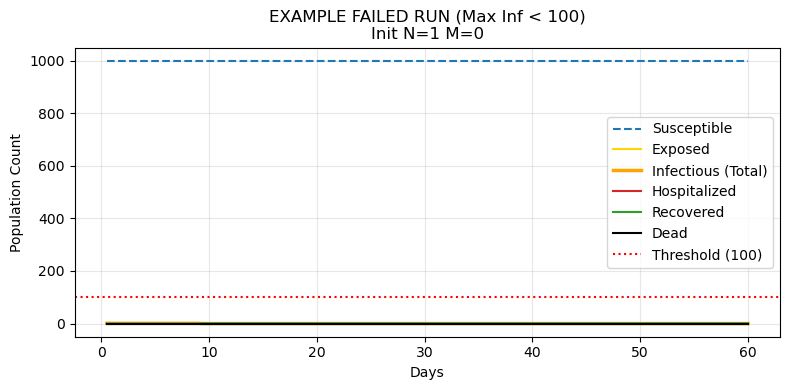


[Visualizing first detected failed run at r=2]


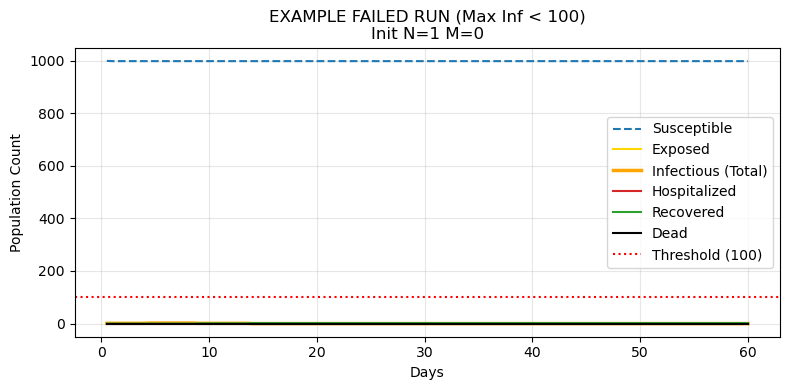


[Visualizing first detected failed run at r=3]


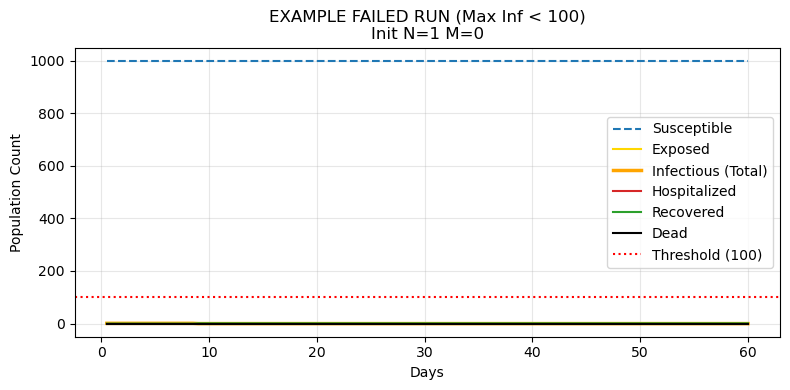


[Visualizing first detected failed run at r=4]


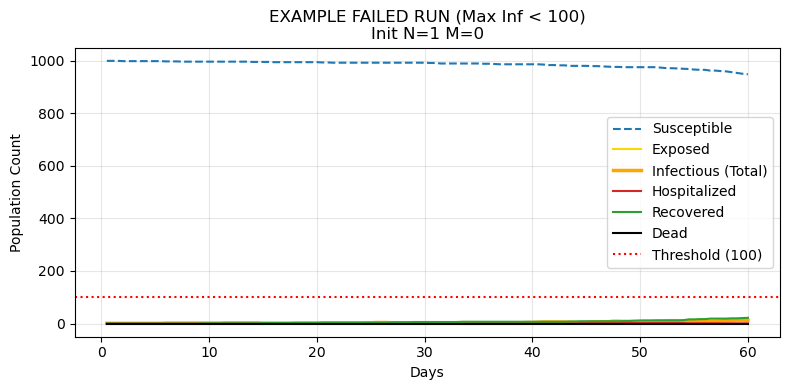


[Visualizing first detected failed run at r=6]


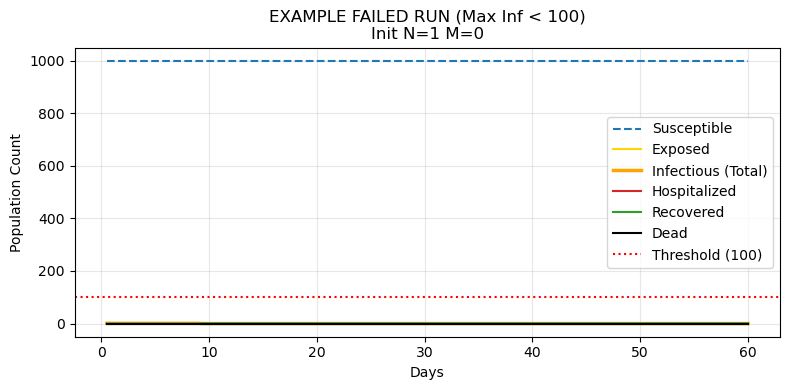


[Visualizing first detected failed run at r=8]


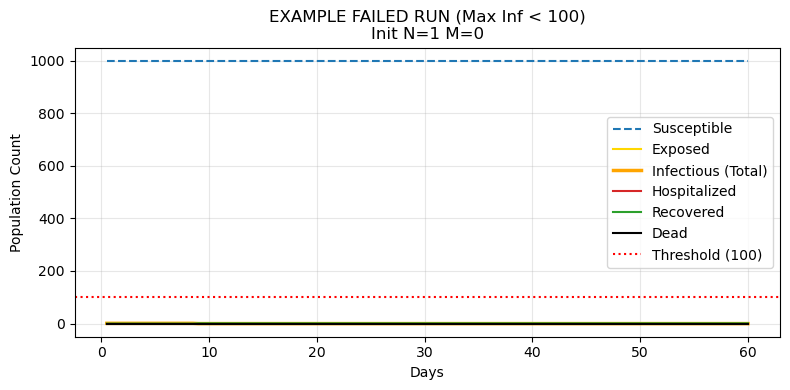


[Visualizing first detected failed run at r=9]


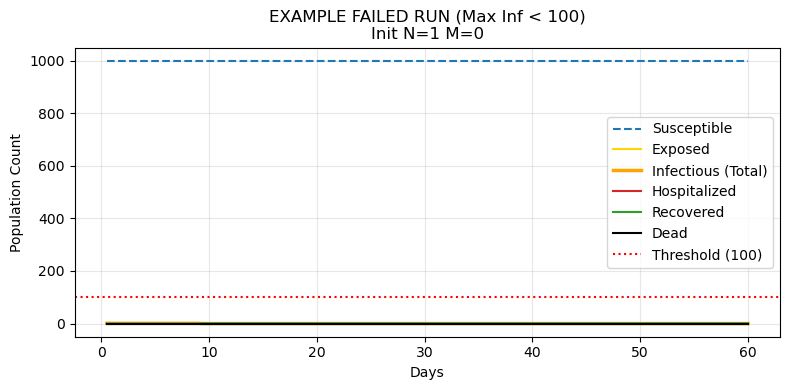

 Done. (Failed: 7/10) (27.39s)
Simulating: Norm=1, Multi=1... Done. (Failed: 0/10) (27.14s)
Simulating: Norm=2, Multi=0...
[Visualizing first detected failed run at r=4]


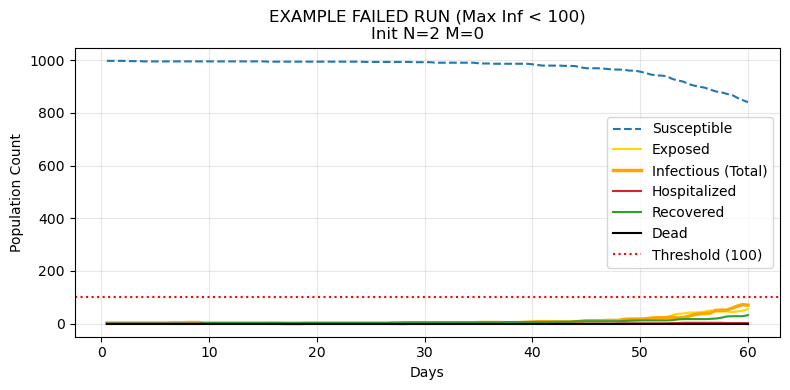

 Done. (Failed: 1/10) (27.66s)
Simulating: Norm=2, Multi=1... Done. (Failed: 0/10) (26.61s)

[Saved] ALL trajectories (success + fail) saved to: grid_sim_AllRuns_N1000_D60_1.csv

--- Loading data from grid_sim_AllRuns_N1000_D60_1.csv for analysis ---


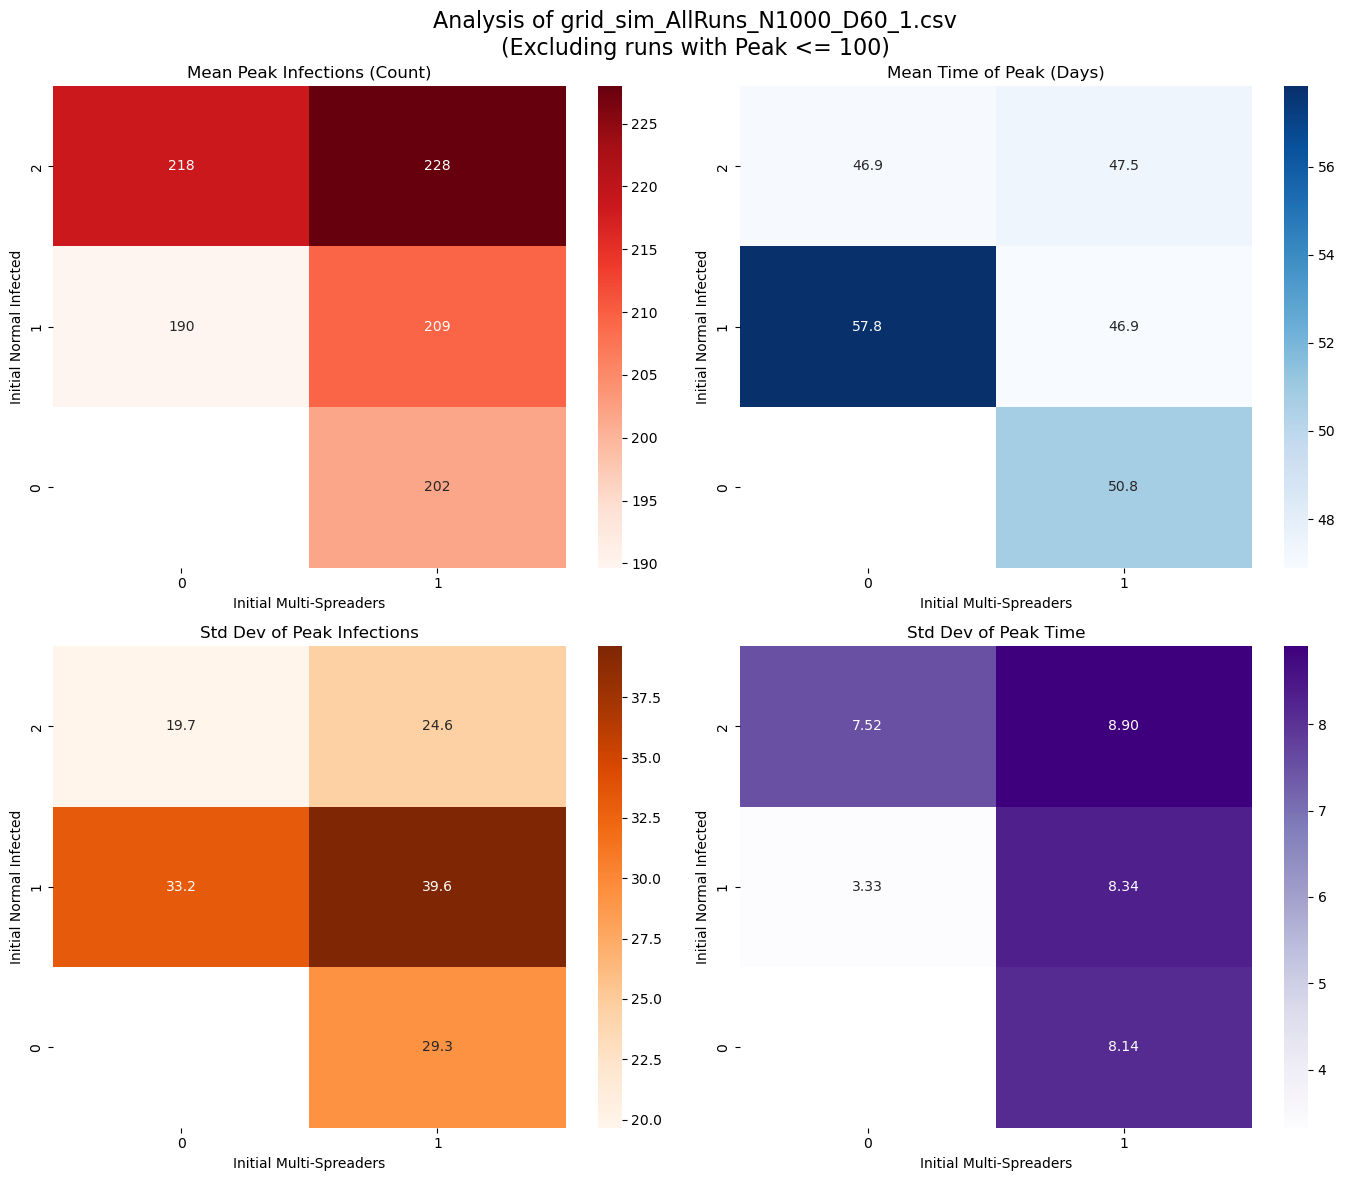

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os
import infection_model as model

# ==========================================
# 1. SETUP & HELPER FUNCTIONS
# ==========================================

def plot_failed_run(df, params, threshold):
    """Plots a single example of a failed run (didn't catch on)."""
    colors = {
        "S": "tab:blue", "E": "gold", "I_total": "orange",
        "H": "tab:red", "R": "tab:green", "D": "black"
    }
    plt.figure(figsize=(8, 4))
    
    if "I_total" not in df.columns:
        df["I_total"] = df["I0"] + df["I1"] + df["I2"]

    plt.plot(df["days"], df["S"], label="Susceptible", color=colors["S"], linestyle="--")
    plt.plot(df["days"], df["E"], label="Exposed", color=colors["E"])
    plt.plot(df["days"], df["I_total"], label="Infectious (Total)", color=colors["I_total"], linewidth=2.5)
    plt.plot(df["days"], df["H"], label="Hospitalized", color=colors["H"])
    plt.plot(df["days"], df["R"], label="Recovered", color=colors["R"])
    plt.plot(df["days"], df["D"], label="Dead", color=colors["D"])

    plt.axhline(y=threshold, color='r', linestyle=':', label=f"Threshold ({threshold})")
    
    plt.xlabel("Days")
    plt.ylabel("Population Count")
    plt.title(f"EXAMPLE FAILED RUN (Max Inf < {threshold})\nInit N={params.initial_infected_normal} M={params.initial_infected_multispreader}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Configuration
NORMAL_RANGE = range(0, 3) 
MULTI_RANGE = range(0, 2)  
REPETITIONS = 10          
DAYS = 60
N_AGENTS = 1000
SPREAD_THRESHOLD = 100      # Threshold to consider a run "successful"

# ==========================================
# 2. SIMULATION PHASE
# ==========================================
print(f"--- Starting Grid Simulation (N={N_AGENTS}, Days={DAYS}) ---")
start_time_total = time.time()

all_trajectories = []
example_failed_plotted = False 

for n_norm in NORMAL_RANGE:
    for n_multi in MULTI_RANGE:
        if n_norm == 0 and n_multi == 0:
            continue
            
        print(f"Simulating: Norm={n_norm}, Multi={n_multi}...", end="", flush=True)
        point_start = time.time()
        failed_spread_count = 0 
        
        for r in range(REPETITIONS):
            params = model.Params(
                T=DAYS * 24,
                N=N_AGENTS,
                alpha=3,
                initial_infected_normal=n_norm,
                initial_infected_multispreader=n_multi,
                ratios=model.AgentTypeRatio(retired=0.2, adult=0.6, child=0.2),
                schools=4,
                primary_care=20,
                hospitals=1,
                other_working_places=100,
                public_places=50
            )
            sim = model.Simulation(params=params)
            sim.init()
            sim.run(dt=12.0)
            
            stats = sim.get_stats_df()
            df = pd.DataFrame(stats)
            
            # Add metadata for identification
            df["run_id"] = r
            df["n_norm"] = n_norm
            df["n_multi"] = n_multi
            df["I_total"] = df["I0"] + df["I1"] + df["I2"]
            df["days"] = df["time"] / 24.0
            
            # Save ALL trajectories (Successful + Failed)
            all_trajectories.append(df)
            
            peak_infections = df["I_total"].max()
            
            # --- Counting & Visual Check Logic ---
            if peak_infections <= SPREAD_THRESHOLD:
                failed_spread_count += 1
                
                
                print(f"\n[Visualizing first detected failed run at r={r}]")
                plot_failed_run(df, params, SPREAD_THRESHOLD)
                example_failed_plotted = True
            
        print(f" Done. (Failed: {failed_spread_count}/{REPETITIONS}) ({time.time() - point_start:.2f}s)")

# ==========================================
# 3. SAVE DATA (ALL RUNS)
# ==========================================
if all_trajectories:
    full_df = pd.concat(all_trajectories, ignore_index=True)
    
    # Filename now indicates it contains "AllRuns"
    base_name = f"grid_sim_AllRuns_N{N_AGENTS}_D{DAYS}"
    
    i = 1
    filename = f"{base_name}_{i}.csv"
    while os.path.exists(filename):
        i += 1
        filename = f"{base_name}_{i}.csv"
        
    full_df.to_csv(filename, index=False)
    print(f"\n[Saved] ALL trajectories (success + fail) saved to: {filename}")
else:
    print("\n[Error] No trajectories generated.")
    filename = None

# ==========================================
# 4. LOAD & ANALYZE (With Exclusion Step)
# ==========================================
if filename and os.path.exists(filename):
    print(f"\n--- Loading data from {filename} for analysis ---")
    
    # A. Read DataFrame
    loaded_df = pd.read_csv(filename)
    
    # B. Process: Calculate Peak Infection for EACH run
    run_groups = loaded_df.groupby(["n_norm", "n_multi", "run_id"])
    
    analysis_stats = []
    
    for (n_n, n_m, r_id), group in run_groups:
        peak_inf = group["I_total"].max()
        
        # --- EXCLUSION LOGIC ---
        # Only process if peak exceeded threshold
        if peak_inf > SPREAD_THRESHOLD:
            peak_idx = group["I_total"].idxmax()
            peak_time = group.loc[peak_idx, "days"]
            
            analysis_stats.append({
                "n_norm": n_n,
                "n_multi": n_m,
                "peak_infections": peak_inf,
                "peak_time": peak_time
            })
    
    # If all runs failed for a specific parameter set, it won't be in analysis_stats
    if not analysis_stats:
        print("[Warning] No runs exceeded the threshold. Cannot plot.")
    else:
        analysis_df = pd.DataFrame(analysis_stats)
        
        # C. Aggregate: Calculate Mean and Std (on SURVIVORS only)
        grouped_stats = analysis_df.groupby(["n_norm", "n_multi"])
        
        mean_peak = grouped_stats["peak_infections"].mean().unstack(level="n_multi")
        std_peak = grouped_stats["peak_infections"].std().unstack(level="n_multi")
        
        mean_time = grouped_stats["peak_time"].mean().unstack(level="n_multi")
        std_time = grouped_stats["peak_time"].std().unstack(level="n_multi")

        # ==========================================
        # 5. PLOTTING HEATMAPS
        # ==========================================
        fig, axes = plt.subplots(2, 2, figsize=(14, 12))
        fig.suptitle(f"Analysis of {filename}\n(Excluding runs with Peak <= {SPREAD_THRESHOLD})", fontsize=16)

        def draw_heatmap(data, ax, title, fmt=".1f", cmap="viridis"):
            sns.heatmap(data, annot=True, fmt=fmt, cmap=cmap, ax=ax, cbar=True)
            ax.set_title(title)
            ax.set_ylabel("Initial Normal Infected")
            ax.set_xlabel("Initial Multi-Spreaders")
            ax.invert_yaxis() 

        # 1. Mean Peak Infections
        draw_heatmap(mean_peak, axes[0, 0], "Mean Peak Infections (Count)", fmt=".0f", cmap="Reds")
        # 2. Time of Peak
        draw_heatmap(mean_time, axes[0, 1], "Mean Time of Peak (Days)", fmt=".1f", cmap="Blues")
        # 3. Std Dev of Peak
        draw_heatmap(std_peak, axes[1, 0], "Std Dev of Peak Infections", fmt=".1f", cmap="Oranges")
        # 4. Std Dev of Time
        draw_heatmap(std_time, axes[1, 1], "Std Dev of Peak Time", fmt=".2f", cmap="Purples")
        
        plt.tight_layout()
        plt.show()